The project motive is I want to create a website, when user upload a image then it will all the color code of every pixel which is help developer to find best color as per their choice.

In [ ]:
import numpy as np

from PIL import Image
from sklearn.cluster import KMeans

In [ ]:
class KMeansPixelModel:
    def __init__(self, k=52):           # more colors usually better
        self.k = k
        self.model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        self.image_array = None
        self.labels = None
        self.centers = None             
        self.width = None
        self.height = None

    def load_and_train(self, image_path):
        image = Image.open(image_path).convert("RGB")
        self.image_array = np.array(image)
        self.height, self.width, _ = self.image_array.shape
        
        pixels = self.image_array.reshape(-1, 3).astype(float)
        
        # Fit and predict in two steps (cleaner)
        self.model.fit(pixels)
        self.labels = self.model.predict(pixels)
        self.centers = self.model.cluster_centers_.astype(int)   

        return {"message": "Model trained", "clusters": self.k}

    # def get_pixel_info(self, x, y):
    #     if self.image_array is None:
    #         raise Exception("Model not trained")
            
    #     if not (0 <= x < self.width and 0 <= y < self.height):
    #         return {"error": "Out of bounds"}
            
    #     index = y * self.width + x
    #     cluster_id = int(self.labels[index])
        
    #     # ← This is the key change
    #     r, g, b = self.centers[cluster_id]           
        
    #     return {
    #         "r": int(r),
    #         "g": int(g),
    #         "b": int(b),
    #         "hex": self.rgb_to_hex(r, g, b),
    #         "cluster": cluster_id,
    #         # optional: also show original for comparison
    #         "original_rgb": tuple(map(int, self.image_array[y, x])),
    #     }
    
    def get_pixel_info(self, x, y):
        if self.image_array is None:
            raise Exception("Model not trained")

        if not (0 <= x < self.width and 0 <= y < self.height):
            return {"error": "Out of bounds"}

        index = y * self.width + x
        cluster_id = int(self.labels[index])

        #  Original pixel
        r, g, b = self.image_array[y, x]

        #  Cluster center
        cr, cg, cb = self.centers[cluster_id]

        return {
            "r": int(r),
            "g": int(g),
            "b": int(b),
            "hex": self.rgb_to_hex(r, g, b),
            "cluster": cluster_id,
            "cluster_color": self.rgb_to_hex(cr, cg, cb),
        }

    def rgb_to_hex(self, r, g, b):
        return f"#{r:02x}{g:02x}{b:02x}"

In [13]:
if __name__ == "__main__":
    model = KMeansPixelModel()

    model.load_and_train(r"C:\Users\HP\Downloads\ZiClJf-1920w.jpg")

    x, y = 90, 200
    result = model.get_pixel_info(x, y)

    print(result)

{'r': 187, 'g': 134, 'b': 99, 'hex': '#bb8663', 'cluster': 134, 'original_rgb': (191, 136, 105)}


In [ ]:
from PIL import Image
import numpy as np

# Load image
image = Image.open(r"C:\Users\HP\Downloads\ZiClJf-1920w.jpg").convert("RGB")

# Convert to numpy array
image_array = np.array(image)

# Flatten image → (num_pixels, 3)
pixels = image_array.reshape(-1, 3)

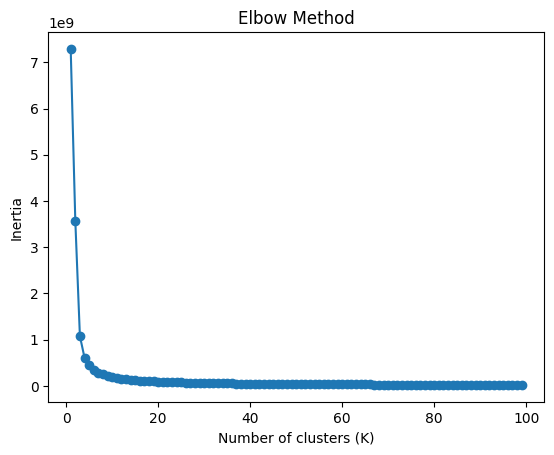

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def find_optimal_k(pixels):
    inertia = []
    k_range = range(1, 100)

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42)
        model.fit(pixels)
        inertia.append(model.inertia_)

    plt.figure()
    plt.plot(k_range, inertia, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.show()
    
pixels_sample = pixels[np.random.choice(len(pixels), 10000, replace=False)]
find_optimal_k(pixels)

In [35]:
import numpy as np
from sklearn.cluster import KMeans
from PIL import Image
import os

def compare_k_values(image_path, k_values=[8, 16, 32, 64, 128]):
    """
    Trains multiple KMeans models and shows:
    - reconstruction error (MSE)
    - saves quantized image for each k
    """
    original_img = Image.open(image_path).convert("RGB")
    original_array = np.array(original_img)                  # shape (H, W, 3)
    pixels = original_array.reshape(-1, 3).astype(np.float32)
    
    results = []
    
    for k in k_values:
        print(f"Processing k = {k} ...")
        
        model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = model.fit_predict(pixels)
        
        # Reconstruct image using cluster centers
        centers = model.cluster_centers_.astype(np.uint8)
        reconstructed_flat = centers[labels]
        reconstructed = reconstructed_flat.reshape(original_array.shape)
        
        # Mean Squared Error (lower = better)
        mse = np.mean((original_array.astype(float) - reconstructed.astype(float)) ** 2)
        rmse = np.sqrt(mse)
        
        # Save result
        quantized_img = Image.fromarray(reconstructed)
        output_name = f"quantized_k{k}.png"
        quantized_img.save(output_name)
        
        results.append({
            "k": k,
            "mse": mse,
            "rmse": rmse,
            "file": output_name,
            "colors_used": k
        })
    
    # Print summary table
    print("\n" + "="*60)
    print(f"{'k':>6} | {'MSE':>12} | {'RMSE':>10} | File")
    print("-"*60)
    for r in results:
        print(f"{r['k']:6} | {r['mse']:12.2f} | {r['rmse']:10.2f} | {r['file']}")
    print("="*60)
    
    print("\nRecommendation:")
    print("→ Open the images and choose the smallest k where you don't see obvious color banding / loss")
    print("→ Common sweet spots: k=24–64 for photos, k=8–32 for icons / simple graphics")
    
    return results




if __name__ == "__main__":
    path = r"C:\Users\HP\Downloads\istockphoto-517188688-1024x1024.jpg"
    
    if not os.path.exists(path):
        print("Image not found. Change the path.")
    else:
        compare_k_values(path, k_values=[8, 16, 32, 64, 96, 128])

Processing k = 8 ...
Processing k = 16 ...
Processing k = 32 ...
Processing k = 64 ...
Processing k = 96 ...
Processing k = 128 ...

     k |          MSE |       RMSE | File
------------------------------------------------------------
     8 |       386.92 |      19.67 | quantized_k8.png
    16 |       208.84 |      14.45 | quantized_k16.png
    32 |       112.49 |      10.61 | quantized_k32.png
    64 |        64.23 |       8.01 | quantized_k64.png
    96 |        46.40 |       6.81 | quantized_k96.png
   128 |        37.36 |       6.11 | quantized_k128.png

Recommendation:
→ Open the images and choose the smallest k where you don't see obvious color banding / loss
→ Common sweet spots: k=24–64 for photos, k=8–32 for icons / simple graphics


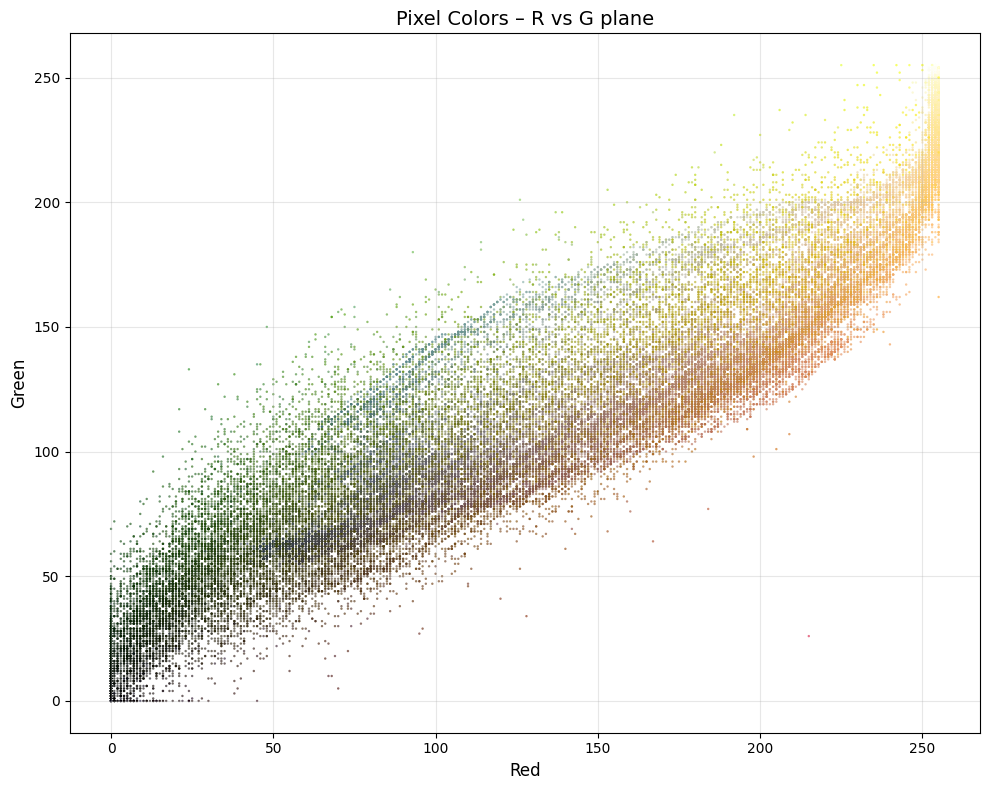

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load your image
img_path = r"C:\Users\HP\Downloads\istockphoto-517188688-1024x1024.jpg"
img = Image.open(img_path).convert("RGB")
pixels = np.array(img)                    # shape: (height, width, 3)
h, w, _ = pixels.shape

# Flatten to (N, 3) and take sample if image is huge
pixels_flat = pixels.reshape(-1, 3)

# Optional: take random sample (faster plot, less memory)
if len(pixels_flat) > 50000:
    indices = np.random.choice(len(pixels_flat), size=50000, replace=False)
    pixels_flat = pixels_flat[indices]

# Plot: R vs G, color = actual RGB
plt.figure(figsize=(10, 8))
plt.scatter(
    pixels_flat[:, 0],          # Red
    pixels_flat[:, 1],          # Green
    c=pixels_flat / 255.0,      # color in [0,1]
    s=3, alpha=0.6,             # small points, semi-transparent
    edgecolors='none'
)

plt.xlabel("Red", fontsize=12)
plt.ylabel("Green", fontsize=12)
plt.title("Pixel Colors – R vs G plane", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()